In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import (train_test_split, GridSearchCV, StratifiedKFold,
                                     cross_validate)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, balanced_accuracy_score,
                             confusion_matrix, make_scorer)
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.metrics import geometric_mean_score

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid", palette="deep")

plt.rcParams.update({
    "axes.grid": True,
    "axes.grid.which": "both",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.35,
    "grid.linewidth": 0.6,
})

In [2]:
# Крок 1. Первинний аналіз даних
# Файл без заголовків - назви колонок беремо з опису (glass.names).
# Id - просто номер зразка, викидаємо. Назви фіч лишаємо стандартні (RI + хімічні символи оксидів).
cols = ["Id", "RI", "Na", "Mg", "Al", "Si", "K", "Ca", "Ba", "Fe", "Type"]
df = pd.read_csv("glass.data", header=None, names=cols).drop(columns="Id")
df.shape

(214, 10)

In [3]:
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [5]:
# Перевірка пропусків
df.isna().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [6]:
# Перевірка дублікатів (після викидання Id один рядок дублюється)
df.duplicated().sum()

np.int64(1)

In [7]:
# Один рядок повністю дублюється - прибираємо, щоб та сама точка не потрапила і в train, і в test
df = df.drop_duplicates().reset_index(drop=True)
df.shape

(213, 10)

In [8]:
# Пропусків немає, один дубль прибрали (лишилось 213 рядків). 9 фіч - усі числові
# (RI + оксиди у вагових відсотках). Type - таргет, багатокласовий (6 класів; клас 4 у даних відсутній).

Type
1    69
2    76
3    17
5    13
6     9
7    29
Name: count, dtype: int64


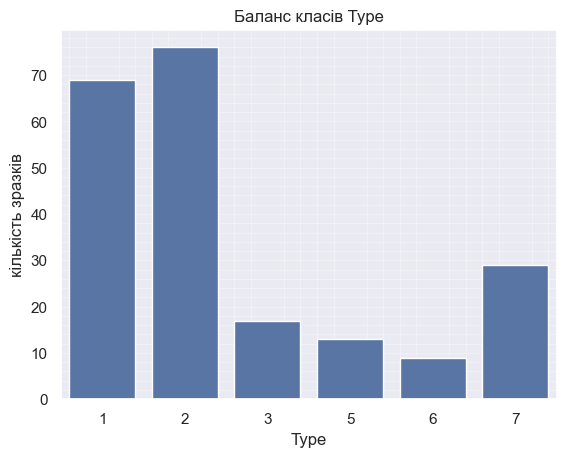

In [9]:
# Баланс класів Type
print(df["Type"].value_counts().sort_index())

sns.countplot(x=df["Type"], order=sorted(df["Type"].unique()))
plt.title("Баланс класів Type")
plt.xlabel("Type")
plt.ylabel("кількість зразків")
plt.show()

In [10]:
# Класи сильно нерівні: найбільший (тип 2) - 76 зразків, найменший (тип 6) - лише 9, тобто ~8:1.
# Це і є наш дисбаланс. Через нього accuracy буде оманливою (модель тягтиме до великих класів),
# тому далі дивитимемось ще й на macro-f1 і balanced_accuracy, а поділ робитимемо зі stratify.

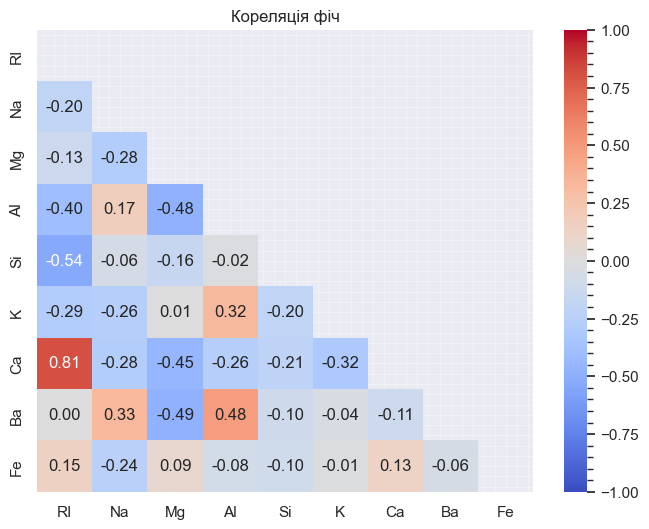

In [11]:
# Крок 2. Графічний аналіз
# Кореляція фіч між собою - чи є дуже схожі (дубльовані) фічі
feature_cols = ["RI", "Na", "Mg", "Al", "Si", "K", "Ca", "Ba", "Fe"]
plt.figure(figsize=(8, 6))
corr = df[feature_cols].corr()
mask = np.triu(corr)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, mask=mask)
plt.title("Кореляція фіч")
plt.show()

In [12]:
# Сильно корелюють лише RI і Ca (0.81) - показник заломлення зростає разом із вмістом кальцію.
# Решта фіч між собою майже незалежні, тобто кожна несе свою інформацію (дубльованих фіч нема).

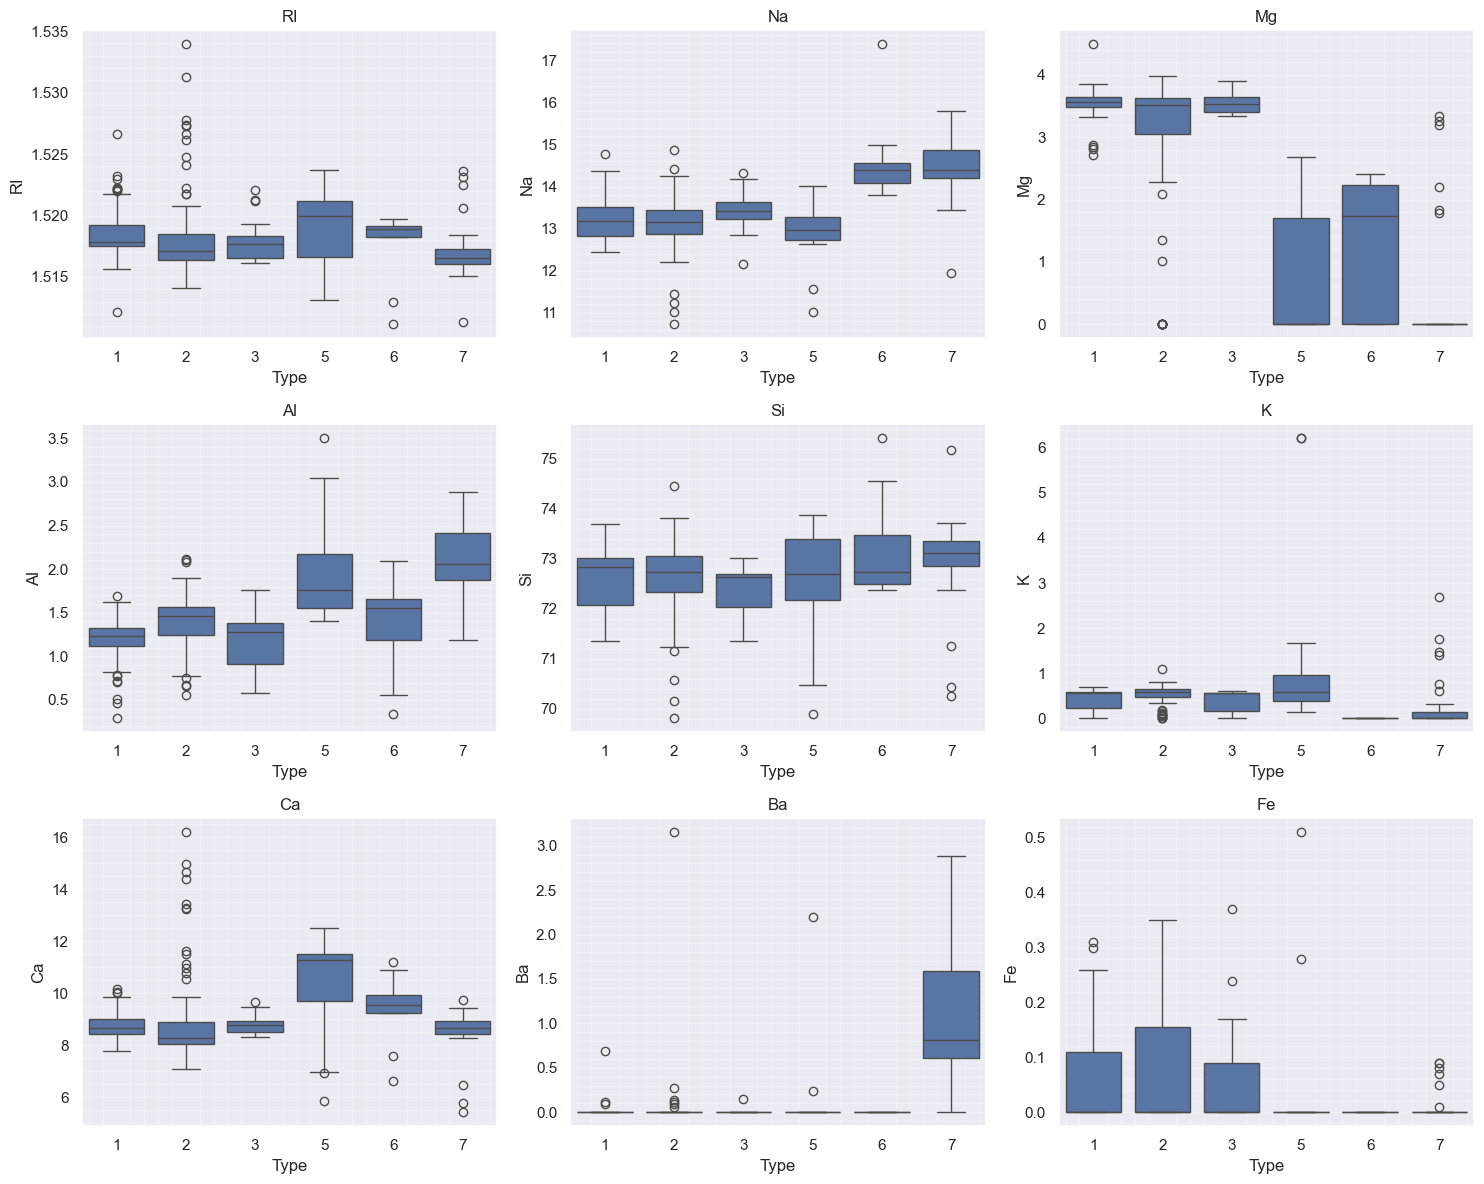

In [13]:
# Як кожна фіча відрізняється по класах (боксплоти в розрізі Type)
order = sorted(df["Type"].unique())
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.ravel(), feature_cols):
    sns.boxplot(data=df, x="Type", y=col, order=order, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [14]:
# Найкраще класи розділяють Mg, Ba, Al і Na:
# - Mg високий у типів 1-3 і низький у 5-7 - добре ділить віконне/невіконне скло;
# - Ba майже нульовий скрізь, окрім типу 7 - фактично сам виділяє цей клас;
# - Al і Na теж помітно різняться між класами.
# А RI, Si, Fe, Ca поодинці класи майже не розділяють (їхні боксплоти сильно перекриваються).

In [15]:
# Крок 3. Фіча-інжиніринг
# Будуємо кілька кандидатів (зі змістом хімії складу), далі виміряємо сигнал і лишимо найкращі.
df["mg_al_diff"] = df["Mg"] - df["Al"]     # Mg високий у віконного скла, Al у невіконного -> різниця розділяє
df["alkali_sum"] = df["Na"] + df["K"]      # сума лужних металів
df["al_si_ratio"] = df["Al"] / df["Si"]    # частка алюмінію відносно кремнію
df["ca_ri_ratio"] = df["Ca"] / df["RI"]    # RI і Ca сильно корелюють - ратіо може щось дати

df[["mg_al_diff", "alkali_sum", "al_si_ratio", "ca_ri_ratio"]].head()

,mg_al_diff,alkali_sum,al_si_ratio,ca_ri_ratio
0,3.39,13.70,0.015325,5.752756
1,2.24,14.37,0.018699,5.159428
2,2.01,13.92,0.021099,5.131317
3,2.40,13.78,0.017766,5.416233
4,2.38,13.82,0.016968,5.318238


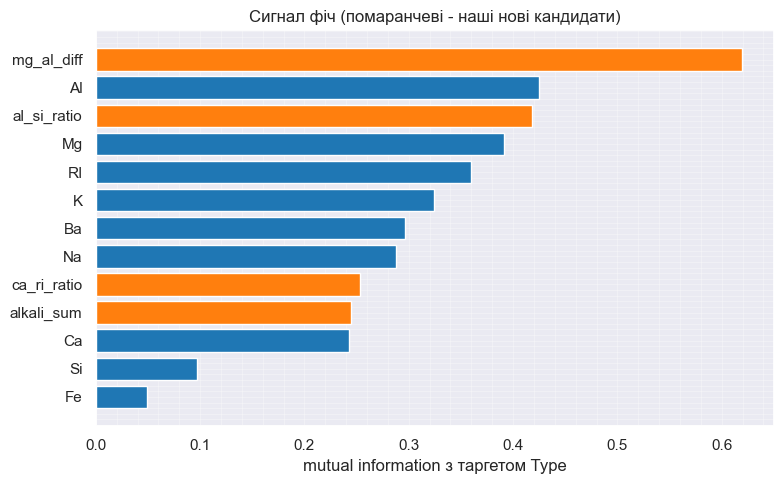

In [16]:
# Міряємо сигнал усіх фіч (вихідні + кандидати) через mutual information з таргетом Type
all_feats = feature_cols + ["mg_al_diff", "alkali_sum", "al_si_ratio", "ca_ri_ratio"]
mi = mutual_info_classif(df[all_feats], df["Type"], random_state=42)
mi = pd.Series(mi, index=all_feats).sort_values()

candidates = ["mg_al_diff", "alkali_sum", "al_si_ratio", "ca_ri_ratio"]
colors = ["tab:orange" if f in candidates else "tab:blue" for f in mi.index]
plt.figure(figsize=(8, 5))
plt.barh(mi.index, mi.values, color=colors)
plt.xlabel("mutual information з таргетом Type")
plt.title("Сигнал фіч (помаранчеві - наші нові кандидати)")
plt.tight_layout()
plt.show()

In [17]:
# mg_al_diff (Mg - Al) має найбільший сигнал з усіх фіч - логічно, бо Mg високий у віконному склі,
# а Al у невіконному, тож їхня різниця добре розділяє класи. Решта кандидатів слабші: al_si_ratio
# майже дублює Al (Si майже сталий), а alkali_sum і ca_ri_ratio дають мало. Найсильніший кандидат -
# mg_al_diff (що з нею робити - у наступній клітинці).

In [18]:
# mg_al_diff має найсильніший сигнал, але вона частково робить ту саму роботу, що й балансування
# (краще розділяє класи, тож моделі й без синтетичних точок легше). А головна мета цієї роботи -
# чесно виміряти саме вплив балансування. Тому свідомо не додаємо mg_al_diff до моделі й відкидаємо
# всіх кандидатів - працюємо на 9 вихідних фічах. (У реальному застосуванні фічу варто було б лишити.)
df = df.drop(columns=["mg_al_diff", "alkali_sum", "al_si_ratio", "ca_ri_ratio"])
df.columns.tolist()

['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type']

In [19]:
# Крок 4. Препроцесинг - поділ train/val/test (stratify) + масштабування
feature_cols_final = feature_cols   # 9 вихідних фіч (mg_al_diff свідомо не додаємо - див. Крок 3)
X = df[feature_cols_final]
y = df["Type"]

# Поділ 60/20/20 зі stratify - 6 класів, найменший = 9, тож частки класів мають зберегтись
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval)
print("train:", len(X_train), "| val:", len(X_val), "| test:", len(X_test))

train: 127 | val: 43 | test: 43


In [20]:
# Перевіряємо, що stratify зберіг класи в кожній частині
pd.DataFrame({"train": y_train.value_counts(), "val": y_val.value_counts(),
              "test": y_test.value_counts()}).sort_index().fillna(0).astype(int)

,train,val,test
Type,,,
1,41,14,14
2,46,15,15
3,10,4,3
5,8,2,3
6,5,2,2
7,17,6,6


In [21]:
# Масштабування: StandardScaler. fit лише на train, val/test тільки трансформуємо.
# Масштаб потрібен для технік балансування (SMOTE/undersampling рахують відстані між точками).
scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols_final, index=X_train.index)
X_val_s = pd.DataFrame(scaler.transform(X_val), columns=feature_cols_final, index=X_val.index)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=feature_cols_final, index=X_test.index)
X_train_s.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
62,1.151408,0.920099,0.777447,-1.374267,-1.558086,-0.814494,0.466432,-0.352739,-0.634917
133,-0.122197,-0.057649,0.804779,-0.389040,0.166568,0.019188,-0.568647,-0.352739,-0.634917
7,-0.290582,-0.267167,0.640788,-0.808286,0.721352,0.099350,-0.489533,-0.352739,-0.634917
70,-0.008919,0.303186,0.818444,-0.347115,-0.822394,0.051253,-0.436790,-0.352739,2.382981
34,-0.207920,-0.802600,0.592958,-0.200380,0.371597,0.099350,-0.153297,-0.352739,-0.634917


In [22]:
# Дані поділено 60/20/20 зі stratify - класи збереглись у всіх частинах (хоч найменших класів у
# val/test лише по кілька зразків - датасет малий). Масштабування навчене лише на train (без витоку).
# train - навчання, val - підбір/порівняння, test - фінальна чесна перевірка.
# Важливо: балансування застосовуватимемо тільки до train, а val/test лишаться з природним дисбалансом.

In [23]:
# Крок 5. Базова модель - RandomForest з дефолтами, без балансування
# Спільна функція оцінки. Дисбаланс -> дивимось не лише на accuracy, а й на macro_f1 та
# balanced_accuracy (вони враховують рідкісні класи нарівні з великими).
def evaluate(model, X, y, name):
    pred = model.predict(X)
    res = {"accuracy": accuracy_score(y, pred),
           "macro_f1": f1_score(y, pred, average="macro"),
           "balanced_acc": balanced_accuracy_score(y, pred)}
    print(f"{name:6} accuracy={res['accuracy']:.3f}  macro_f1={res['macro_f1']:.3f}  "
          f"balanced_acc={res['balanced_acc']:.3f}")
    return res

In [24]:
rf_base = RandomForestClassifier(random_state=42).fit(X_train_s, y_train)
print("Базова модель (без балансування):")
evaluate(rf_base, X_train_s, y_train, "train")
base_val = evaluate(rf_base, X_val_s, y_val, "val")

Базова модель (без балансування):
train  accuracy=1.000  macro_f1=1.000  balanced_acc=1.000
val    accuracy=0.744  macro_f1=0.765  balanced_acc=0.766


In [25]:
# Базова модель: на val accuracy 0.744, macro_f1 0.765, balanced_acc 0.766 - приблизно в діапазоні
# референсу UCI (RF ~84%; наш val лише 43 рядки, тож можливий розкид). На train усе 1.0 - ліс точно
# запам'ятовує train. macro_f1 і balanced_acc не нижчі за accuracy - тобто рідкісні класи модель
# поки що не ігнорує. Побачимо, чи балансування щось додасть.

In [26]:
# Крок 6. Підбір гіперпараметрів RandomForest (GridSearchCV, StratifiedKFold(5), scoring=f1_macro)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {"n_estimators": [100, 300], "max_depth": [None, 6, 12],
     "min_samples_leaf": [1, 3, 5], "max_features": ["sqrt", None]},
    scoring="f1_macro", cv=cv, n_jobs=-1).fit(X_train_s, y_train)
best_rf = rf_grid.best_estimator_
print("найкращі параметри:", rf_grid.best_params_)
print("cv f1_macro:", round(rf_grid.best_score_, 3))

найкращі параметри: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'n_estimators': 100}
cv f1_macro: 0.628


In [27]:
# Порівняння базова vs налаштована на val
print("Базова (дефолти):")
evaluate(rf_base, X_val_s, y_val, "val")
print("Налаштована:")
tuned_val = evaluate(best_rf, X_val_s, y_val, "val")

Базова (дефолти):
val    accuracy=0.744  macro_f1=0.765  balanced_acc=0.766
Налаштована:
val    accuracy=0.814  macro_f1=0.847  balanced_acc=0.832


In [28]:
# Підбір майже не змінив модель: єдина відмінність від дефолтів - max_features=None замість 'sqrt'
# (виграш мінімальний, cv f1_macro 0.628). Для порівняння балансування далі беремо стандартний
# RandomForest із дефолтами - щоб порівнювати саме вплив балансування, а не налаштування моделі.

In [29]:
# Крок 7. Усунення дисбалансу і перевірка впливу
# Кожну техніку загортаємо в imblearn.Pipeline (scaler -> семплер -> модель) і оцінюємо крос-валідацією.
# Scaler тепер усередині пайплайна: він навчається на кожному train-фолді окремо (без витоку), і
# семплінг теж застосовується лише до train-фолдів - val/test лишаються з природним дисбалансом.
# Тому тут працюємо з нешкальованим X_train. SMOTE-варіанти беруть k_neighbors=3, бо найменший клас малий.
def scaler_step():
    return ("scaler", StandardScaler())

def rf(**k):
    return RandomForestClassifier(random_state=42, **k)

techniques = {
    "baseline": Pipeline([scaler_step(), ("m", rf())]),
    "class_weight": Pipeline([scaler_step(), ("m", rf(class_weight="balanced"))]),
    "RandomOverSampler": Pipeline([scaler_step(), ("s", RandomOverSampler(random_state=42)), ("m", rf())]),
    "SMOTE": Pipeline([scaler_step(), ("s", SMOTE(k_neighbors=3, random_state=42)), ("m", rf())]),
    "BorderlineSMOTE": Pipeline([scaler_step(), ("s", BorderlineSMOTE(k_neighbors=3, random_state=42)), ("m", rf())]),
    "ADASYN": Pipeline([scaler_step(), ("s", ADASYN(n_neighbors=3, random_state=42)), ("m", rf())]),
    "RandomUnderSampler": Pipeline([scaler_step(), ("s", RandomUnderSampler(random_state=42)), ("m", rf())]),
    "SMOTETomek": Pipeline([scaler_step(), ("s", SMOTETomek(smote=SMOTE(k_neighbors=3, random_state=42), random_state=42)), ("m", rf())]),
    "BalancedRandomForest": Pipeline([scaler_step(), ("m", BalancedRandomForestClassifier(
        random_state=42, sampling_strategy="all", replacement=True, bootstrap=False))]),
}

gmean = make_scorer(geometric_mean_score, average="macro")
scoring = {"f1_macro": "f1_macro", "balanced_acc": "balanced_accuracy",
           "gmean": gmean, "accuracy": "accuracy"}

rows = {}
for name, pipe in techniques.items():
    try:
        r = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)
        rows[name] = {m: r[f"test_{m}"].mean() for m in scoring}
    except Exception as e:
        print(f"{name}: не спрацював - {type(e).__name__}: {str(e)[:70]}")
        rows[name] = {m: float("nan") for m in scoring}

compare = pd.DataFrame(rows).T.round(3)
compare

,f1_macro,balanced_acc,gmean,accuracy
baseline,0.616,0.648,0.777,0.732
class_weight,0.661,0.709,0.813,0.693
RandomOverSampler,0.686,0.718,0.822,0.740
SMOTE,0.695,0.719,0.823,0.748
BorderlineSMOTE,0.701,0.733,0.831,0.740
ADASYN,NaN,NaN,NaN,NaN
RandomUnderSampler,0.544,0.625,0.742,0.494
SMOTETomek,0.698,0.717,0.821,0.740
BalancedRandomForest,0.575,0.654,0.771,0.582


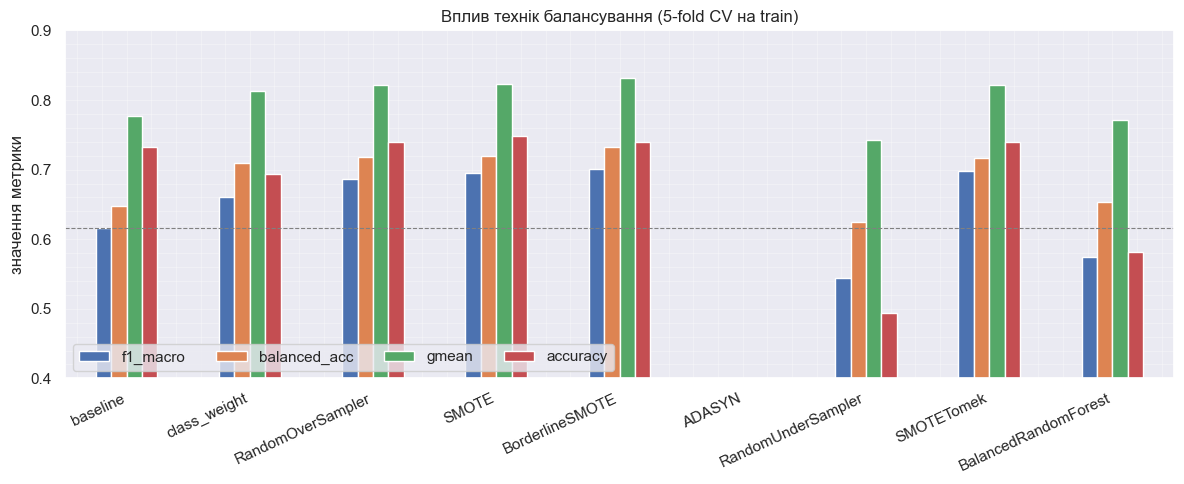

In [30]:
# Порівняння технік на графіку (пунктир - рівень baseline по f1_macro)
compare.plot(kind="bar", figsize=(12, 5))
plt.title("Вплив технік балансування (5-fold CV на train)")
plt.ylabel("значення метрики")
plt.xticks(rotation=25, ha="right")
plt.ylim(0.4, 0.9)
plt.axhline(compare.loc["baseline", "f1_macro"], color="gray", ls="--", lw=0.8)
plt.legend(loc="lower left", ncol=4)
plt.tight_layout()
plt.show()

In [31]:
# Головний висновок про вплив балансування (модель на 9 вихідних фічах - чесна оцінка):
# - Балансування чітко допомагає: baseline f1_macro 0.616 -> усі oversampling-методи 0.686-0.701
#   (BorderlineSMOTE найкраща: gmean 0.777 -> 0.831). class_weight теж піднімає (0.616 -> 0.661).
#   Вони підтягують рідкісні класи, тому ростуть macro_f1, balanced_acc і gmean.
# - RandomUnderSampler і BalancedRandomForest навпаки гірші за f1_macro (0.544 / 0.575): вони
#   викидають частину зразків великих класів, а на малому датасеті це шкодить (accuracy падає до 0.494 / 0.582).
# - ADASYN не спрацював: генерує точки лише в "складних" зонах, а тут рідкісні класи не оточені
#   мажоритарними, тож додавати не було чого.

In [32]:
# Чому не всі відомі методи балансування тут доречні:
# - Undersampling, що чистить мажоритарний клас (Tomek Links, Condensed NN, One-sided selection,
#   Neighborhood Cleaning), тут не пасує: датасет крихітний (127 у train, найменший клас = 5), а ці
#   методи видаляють зразки. Коли даних мало, правильніший oversampling - і RandomUnderSampler вище
#   це підтвердив (accuracy впала до 0.494). Тож ці методи лише зменшили б і так малі дані.
# - One-Class Learning (OneClassSVM, EllipticEnvelope) розрахований на бінарну задачу: навчитись на
#   одному класі й ловити решту як викиди. У нас 6 класів, тож напряму не лягає.

In [33]:
# Крок 8. Фінальна оцінка на test - baseline vs найкраща техніка (BorderlineSMOTE)
# Пайплайни зі scaler усередині: fit на всьому train, оцінка на непочепаному test.
final_models = {
    "baseline": Pipeline([("scaler", StandardScaler()), ("m", RandomForestClassifier(random_state=42))]),
    "BorderlineSMOTE": Pipeline([("scaler", StandardScaler()),
                                 ("s", BorderlineSMOTE(k_neighbors=3, random_state=42)),
                                 ("m", RandomForestClassifier(random_state=42))]),
}
rows = {}
for name, model in final_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rows[name] = {
        "accuracy": accuracy_score(y_test, pred),
        "macro_f1": f1_score(y_test, pred, average="macro"),
        "balanced_acc": balanced_accuracy_score(y_test, pred),
        "gmean": geometric_mean_score(y_test, pred, average="macro"),
    }
pd.DataFrame(rows).T.round(3)

,accuracy,macro_f1,balanced_acc,gmean
baseline,0.86,0.849,0.844,0.903
BorderlineSMOTE,0.86,0.859,0.887,0.927


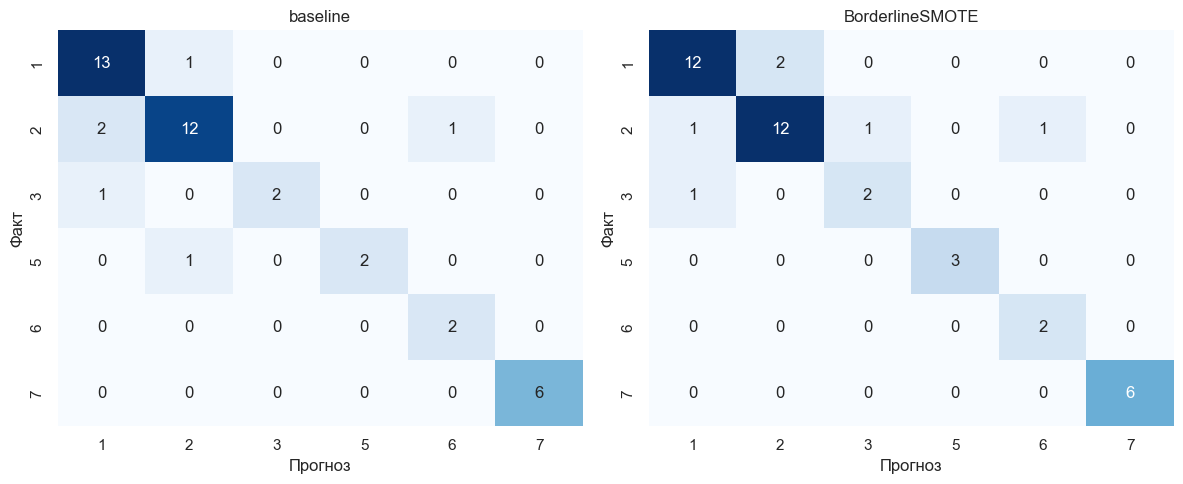

In [34]:
# Матриці помилок на test: baseline vs BorderlineSMOTE
labels = sorted(y.unique())
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, model) in zip(axes, final_models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test), labels=labels)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Прогноз")
    ax.set_ylabel("Факт")
plt.tight_layout()
plt.show()

In [35]:
# На test BorderlineSMOTE тепер краща за baseline: та сама accuracy (0.860), але вищі macro_f1
# (0.849 -> 0.859), balanced_acc (0.844 -> 0.887) і gmean (0.903 -> 0.927). Тобто балансування
# підтягнуло рідкісні класи, не втративши загальної точності.
# Матриці помилок показують конкретно: baseline пропускає один зразок класу 5 (контейнери) - віддає
# його класу 2, а BorderlineSMOTE ловить усі 3 зразки класу 5. Решта помилок в обох - плутанина між
# двома великими класами 1 і 2 (схожі за складом), і її балансування не виправляє.

In [36]:
# Підсумок
# Класифікація типу скла (Glass, 6 класів, дисбаланс ~8:1) на RandomForest. Задача - усунути
# дисбаланс і перевірити вплив на точність. Модель навчали на 9 вихідних фічах (без інженерних -
# щоб чесно виміряти саме ефект балансування).
# Порівняли baseline з 8 техніками балансування (class_weight, over/under-sampling, SMOTE-варіанти,
# BalancedRandomForest) через крос-валідацію; найкращу перевірили на test.
# Головний висновок: балансування допомагає. Oversampling (SMOTE-варіанти) на CV підняв f1_macro
# 0.616 -> ~0.70, а на незалежному test BorderlineSMOTE побив baseline за macro_f1/balanced_acc/gmean
# при тій самій accuracy (0.860) - підтягнув рідкісні класи (напр. усі зразки класу 5). Undersampling
# навпаки шкодить (даних мало). Основні помилки, що лишаються, - між двома великими класами 1 і 2.